# Proyek Akhir: Deteksi Dini Dropout Mahasiswa Jaya Jaya Institut

- **Nama**: Jibran Tsaqif
- **Email**: jibrantsaqif721@gmail.com
- **Id Dicoding**: jibrantsaqif


## 1. Persiapan
### 1.1 Menyiapkan Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully.')


Libraries loaded successfully.


### 1.2 Menyiapkan Data

In [2]:
df = pd.read_csv('data.csv', sep=';')
pd.set_option('display.max_columns', None)
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Data Understanding
### 2.1 Informasi Dataset

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Cek missing values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values.')
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


Missing values per kolom:
Tidak ada missing values.

Total missing values: 0


In [5]:
# Statistik deskriptif
df.describe().round(2)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


In [6]:
# Distribusi Target (Status)
print('Distribusi kolom Status:')
print(df['Status'].value_counts())
print(f'\nPersentase:')
print(df['Status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Distribusi kolom Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93%
Dropout     32.12%
Enrolled    17.95%
Name: proportion, dtype: object


## 3. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, pola, tren, dan hubungan antar variabel.
Terdiri dari:
- **EDA Univariate**: Distribusi masing-masing variabel secara terpisah
- **EDA Multivariat**: Hubungan antara dua atau lebih variabel
- **EDA Numerikal**: Fokus pada fitur numerik
- **EDA Kategorikal**: Fokus pada fitur kategorikal


### 3.1 EDA Univariate — Distribusi Status Mahasiswa

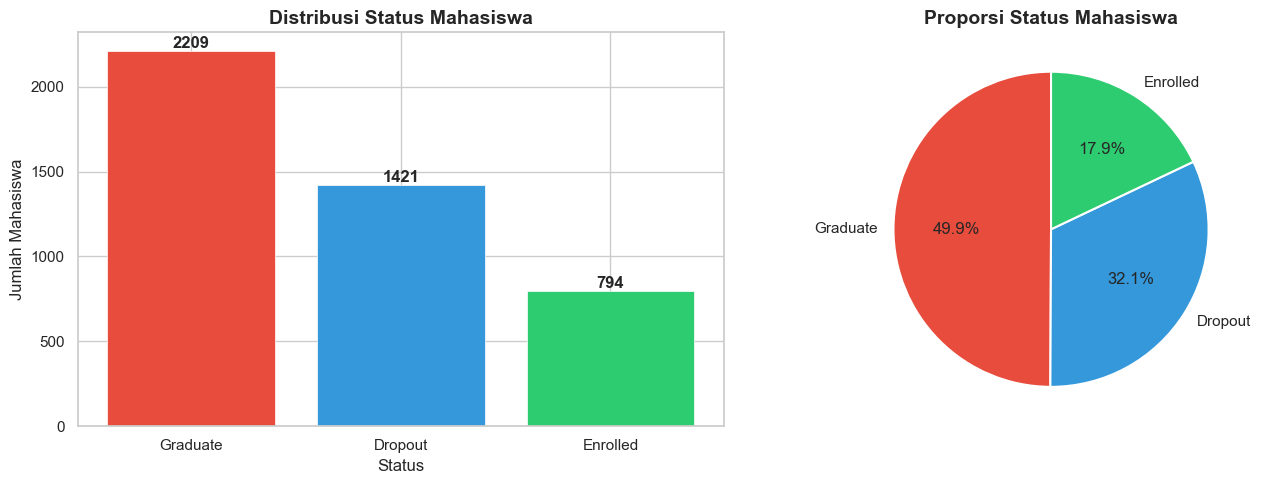

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
status_counts = df['Status'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (val, bar_x) in enumerate(zip(status_counts.values, status_counts.index)):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    status_counts.values, labels=status_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.2 EDA Univariate — Distribusi Fitur Numerik

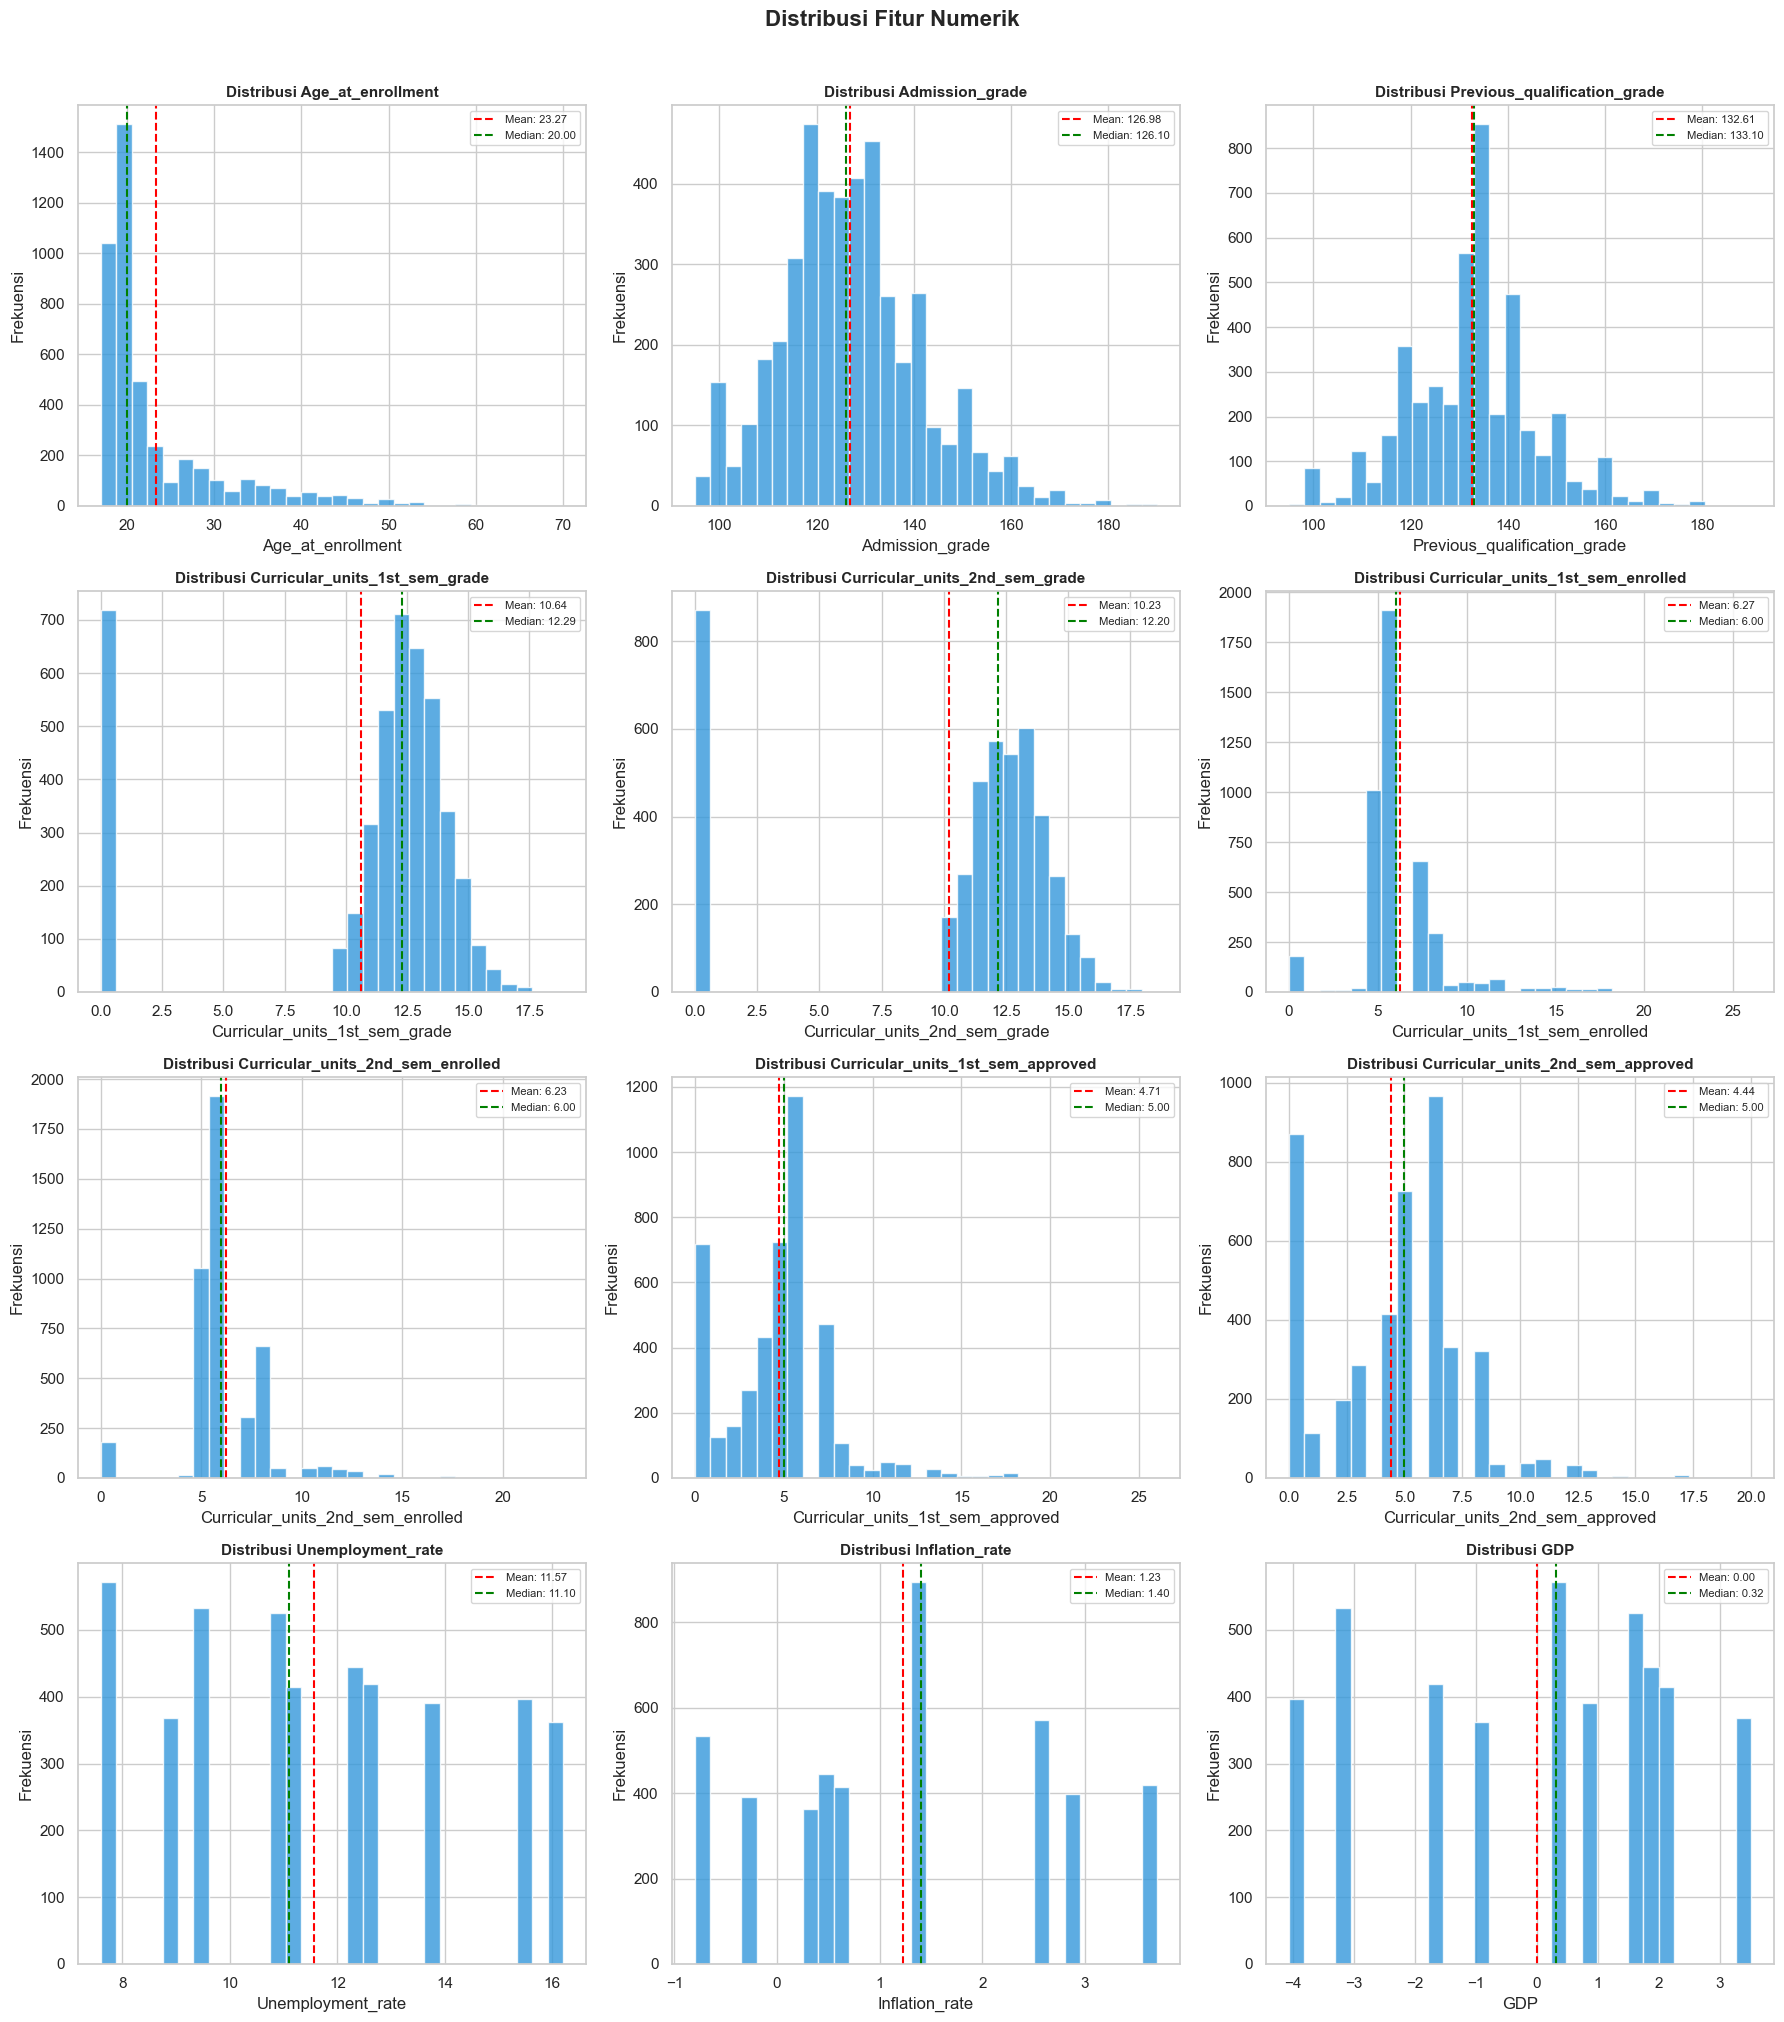

In [8]:
# Fitur numerik yang relevan
numerical_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.3 EDA Univariate — Distribusi Fitur Kategorikal

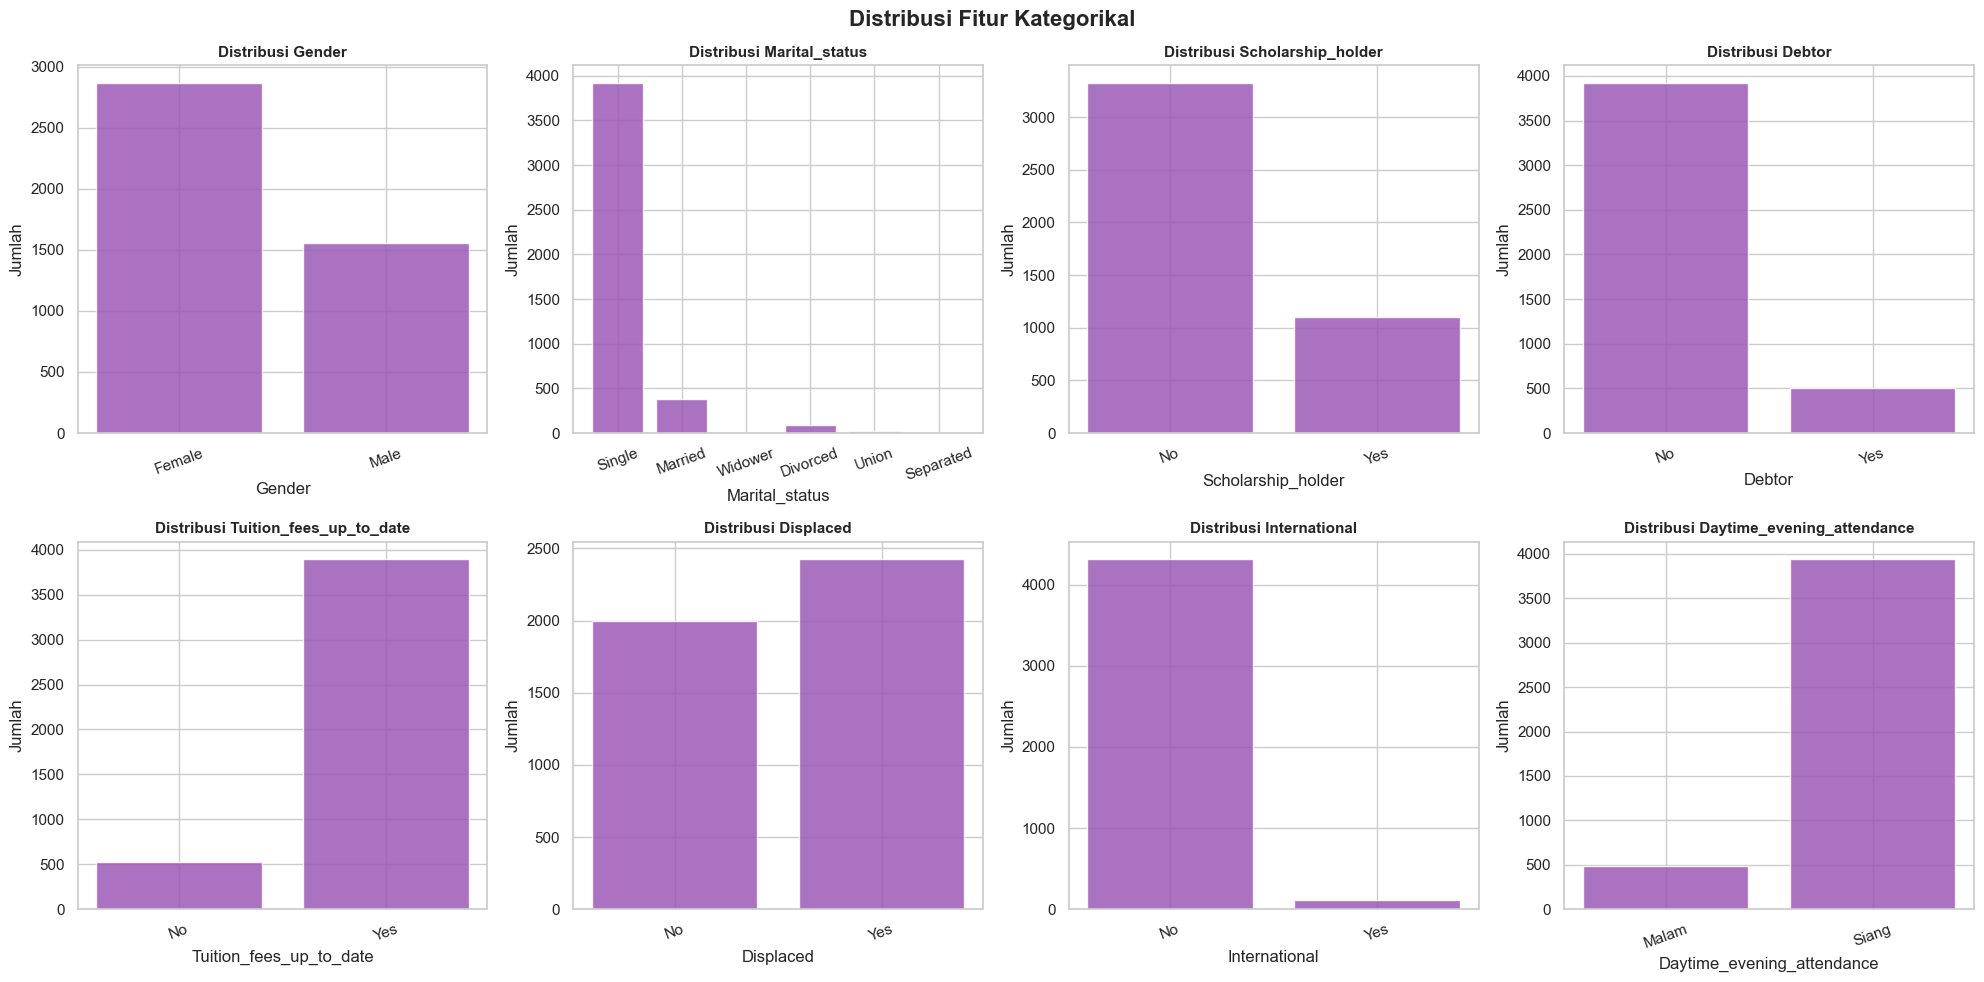

In [9]:
categorical_cols = ['Gender', 'Marital_status', 'Scholarship_holder', 'Debtor',
                    'Tuition_fees_up_to_date', 'Displaced', 'International',
                    'Daytime_evening_attendance']

label_map = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Scholarship_holder': {0: 'No', 1: 'Yes'},
    'Debtor': {0: 'No', 1: 'Yes'},
    'Tuition_fees_up_to_date': {0: 'No', 1: 'Yes'},
    'Displaced': {0: 'No', 1: 'Yes'},
    'International': {0: 'No', 1: 'Yes'},
    'Daytime_evening_attendance': {0: 'Malam', 1: 'Siang'},
    'Marital_status': {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Union', 6: 'Separated'},
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().sort_index()
    if col in label_map:
        counts.index = [label_map[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(counts.index.astype(str), counts.values, color='#9b59b6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 EDA Multivariat — Fitur Kategorikal vs Status Mahasiswa

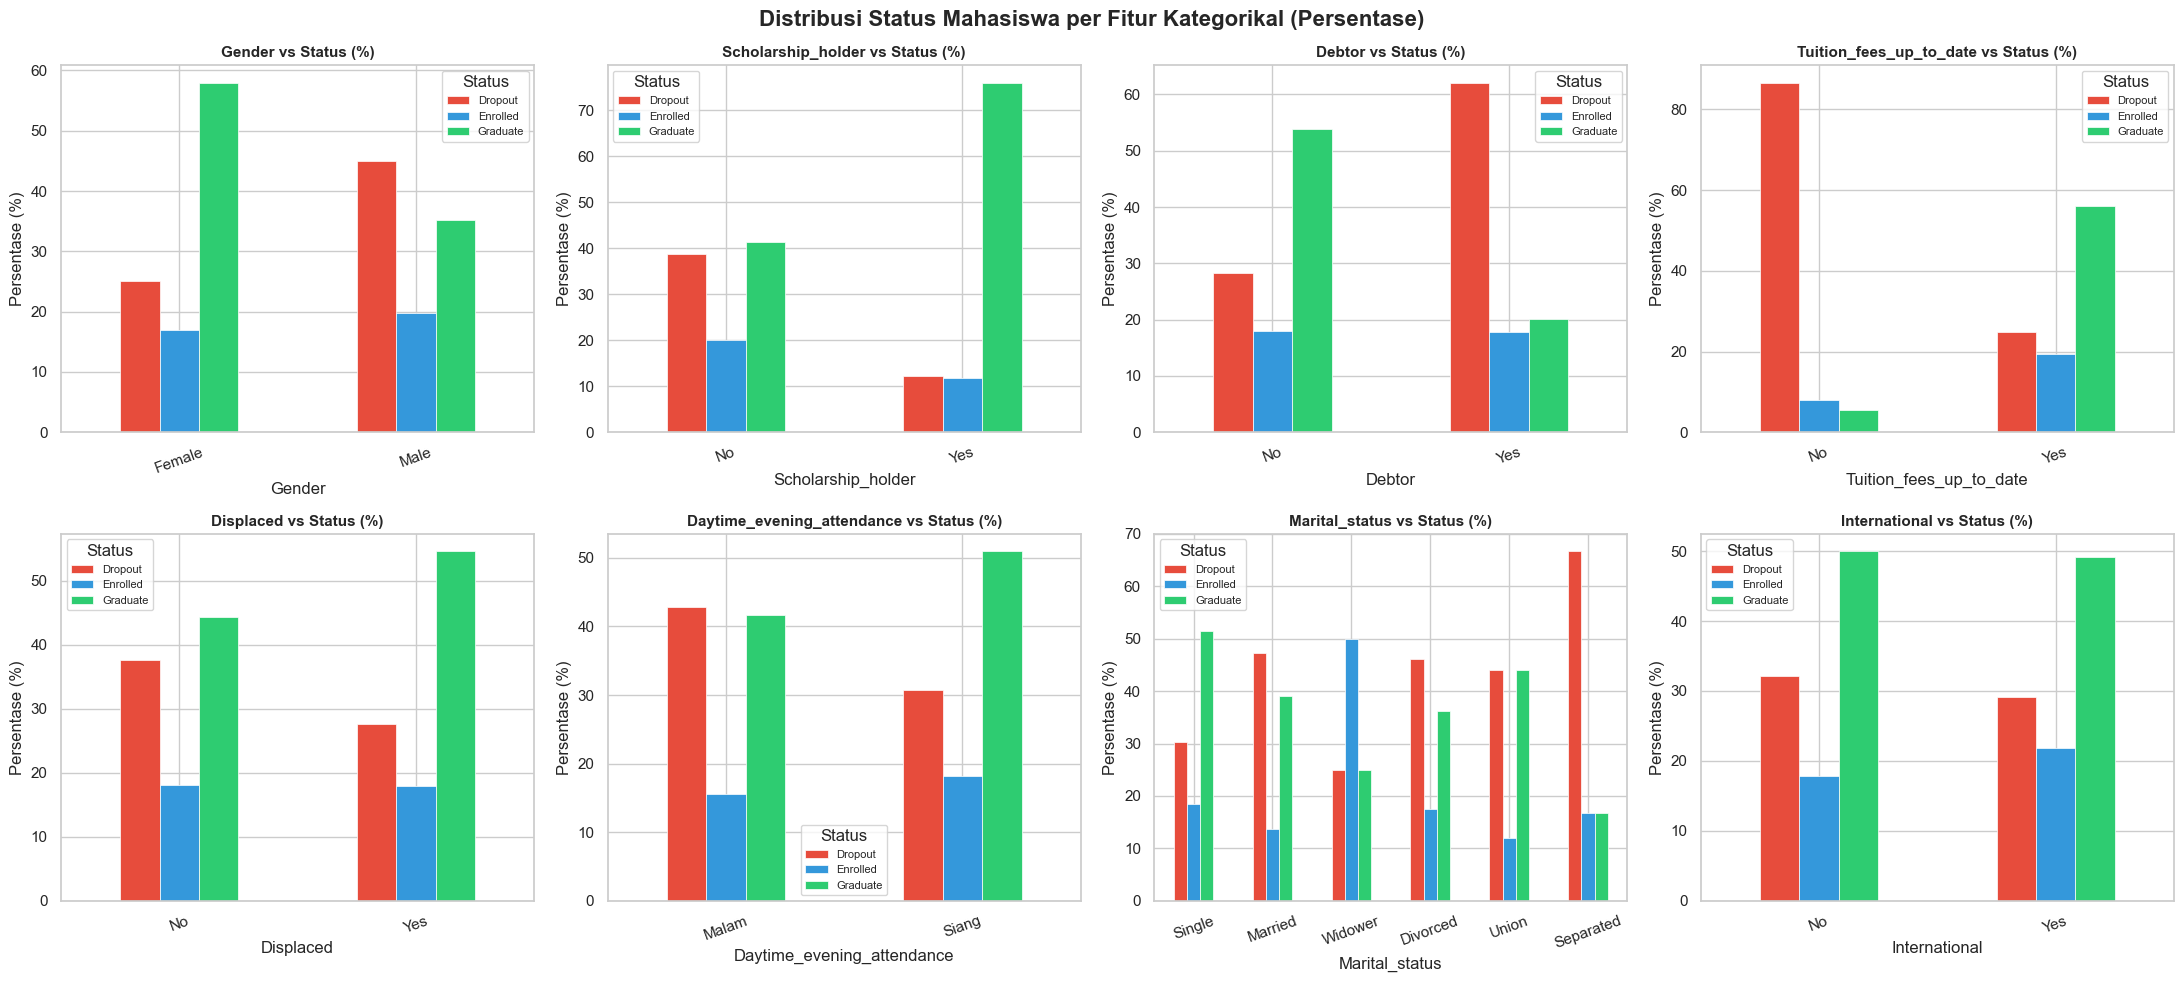

In [10]:
cat_features = ['Gender', 'Scholarship_holder', 'Debtor', 'Tuition_fees_up_to_date',
                'Displaced', 'Daytime_evening_attendance', 'Marital_status', 'International']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

palette = {'Dropout': '#e74c3c', 'Graduate': '#2ecc71', 'Enrolled': '#3498db'}

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['Status'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=[palette.get(c, '#95a5a6') for c in ct_pct.columns],
               edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col} vs Status (%)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='Status', fontsize=8)
    if col in label_map:
        axes[i].set_xticklabels([label_map[col].get(int(t.get_text()), t.get_text())
                                   for t in axes[i].get_xticklabels()], rotation=20)

plt.suptitle('Distribusi Status Mahasiswa per Fitur Kategorikal (Persentase)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.5 EDA Multivariat — Status Mahasiswa per Course (Top 10)

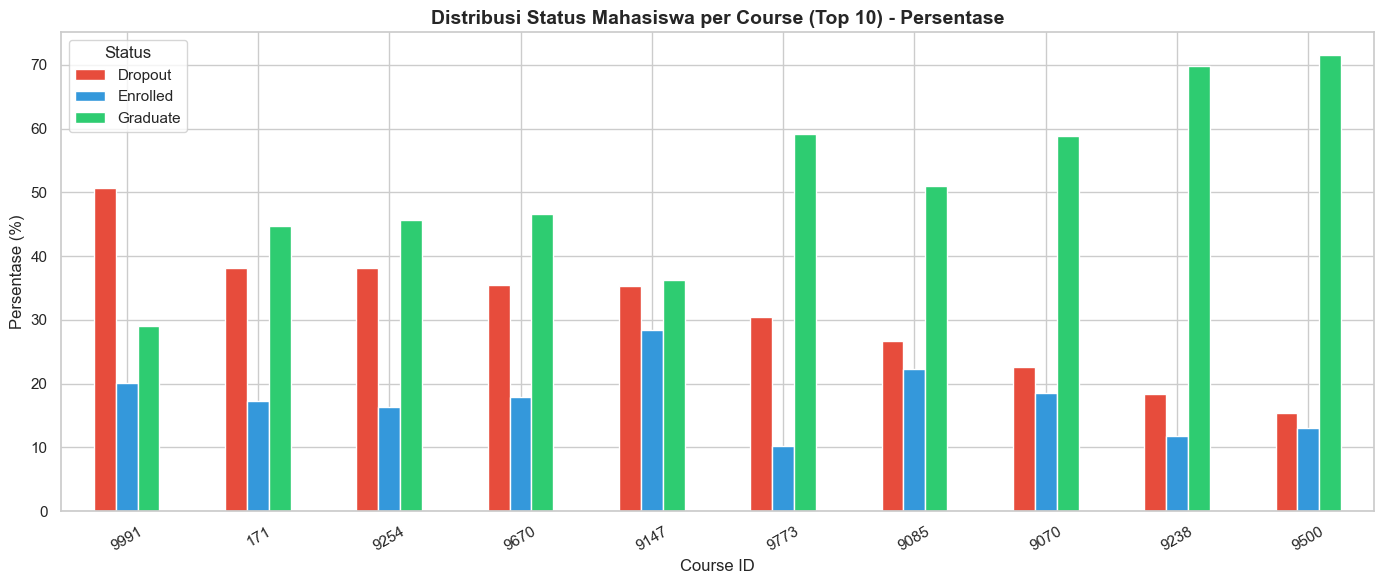

In [11]:
top_courses = df['Course'].value_counts().head(10).index
df_top = df[df['Course'].isin(top_courses)]

ct = pd.crosstab(df_top['Course'], df_top['Status'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct.sort_values('Dropout', ascending=False)

ax = ct_pct.plot(kind='bar', figsize=(14, 6), color=[palette.get(c, '#95a5a6') for c in ct_pct.columns],
                edgecolor='white')
ax.set_title('Distribusi Status Mahasiswa per Course (Top 10) - Persentase', fontsize=14, fontweight='bold')
ax.set_xlabel('Course ID')
ax.set_ylabel('Persentase (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Status')
plt.tight_layout()
plt.show()


### 3.6 EDA Numerik — Distribusi Fitur Numerik per Status

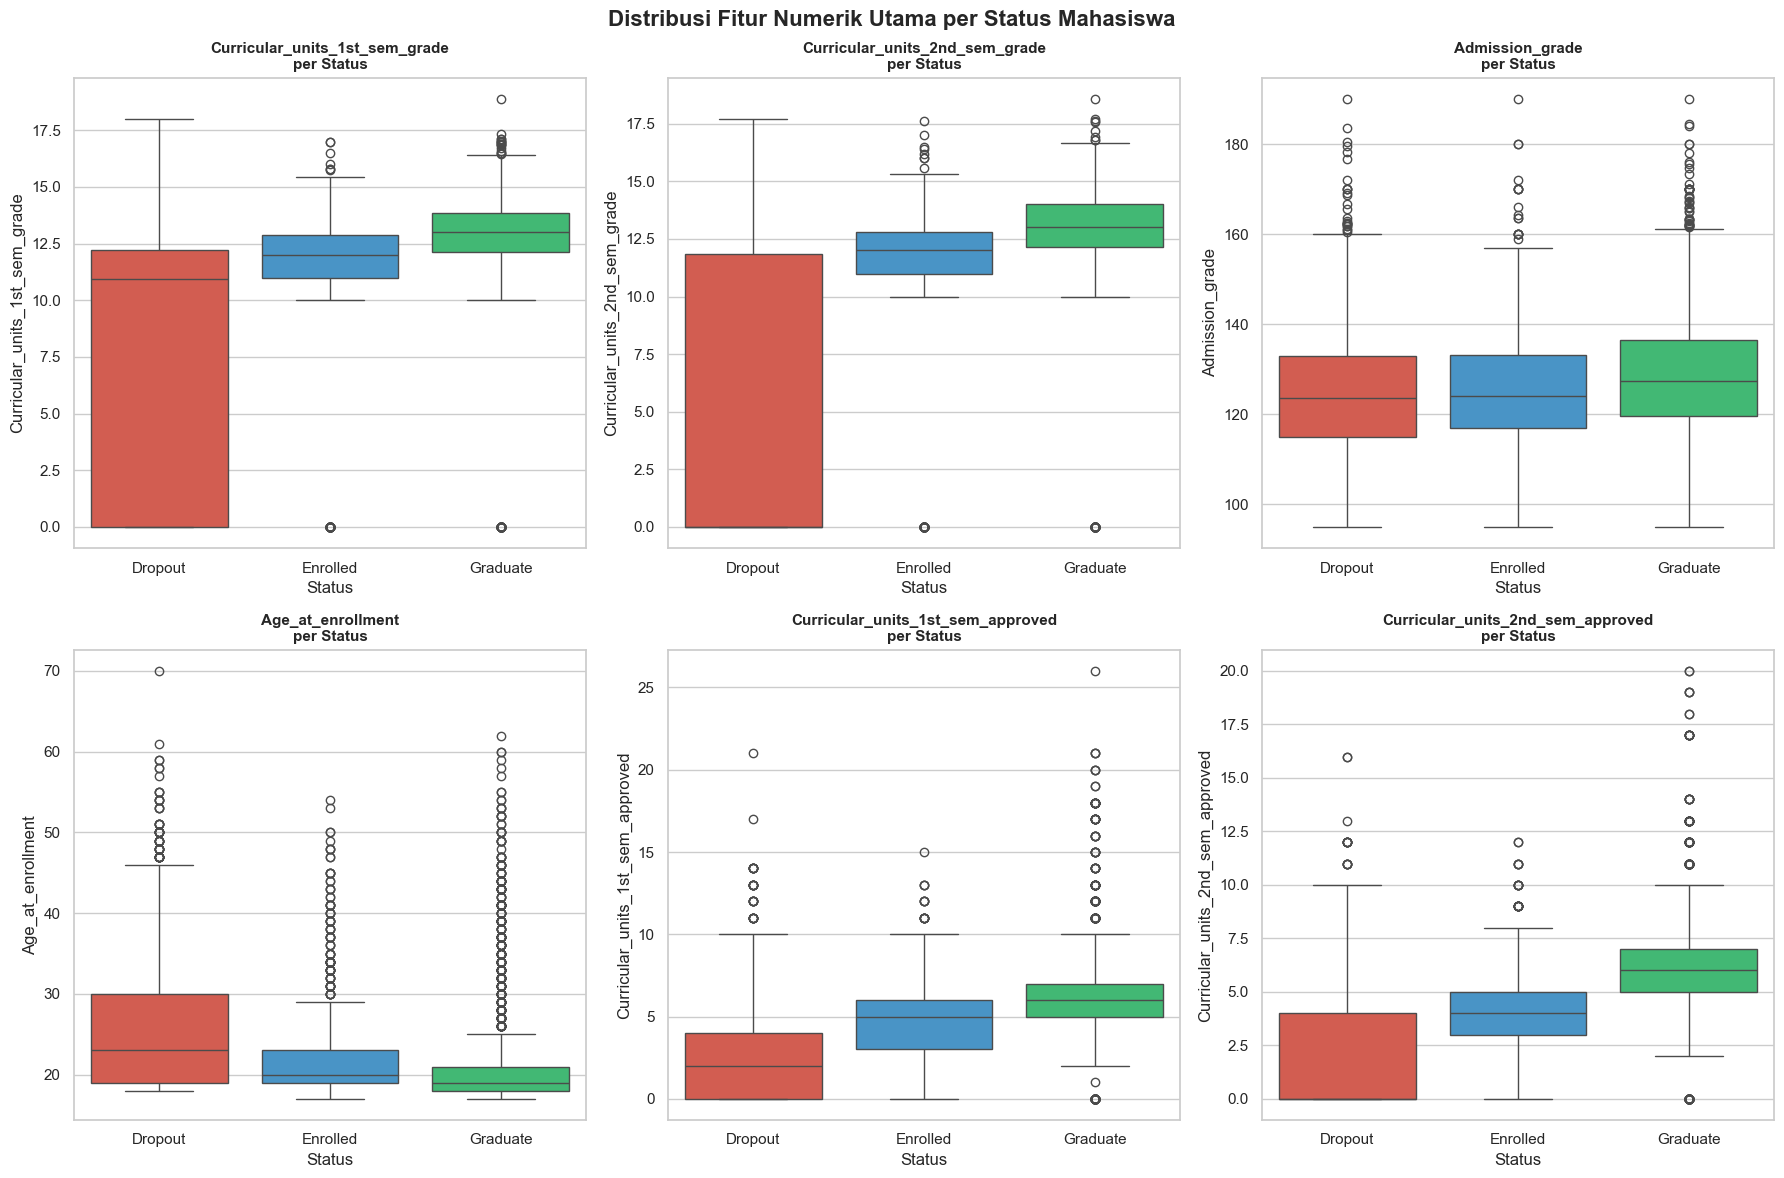

In [12]:
num_features = [
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Admission_grade', 'Age_at_enrollment',
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Status', y=col, palette=palette, ax=axes[i], order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(f'{col}\nper Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Status')
    axes[i].set_ylabel(col)

plt.suptitle('Distribusi Fitur Numerik Utama per Status Mahasiswa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.7 EDA Multivariat — Heatmap Korelasi Fitur Numerik

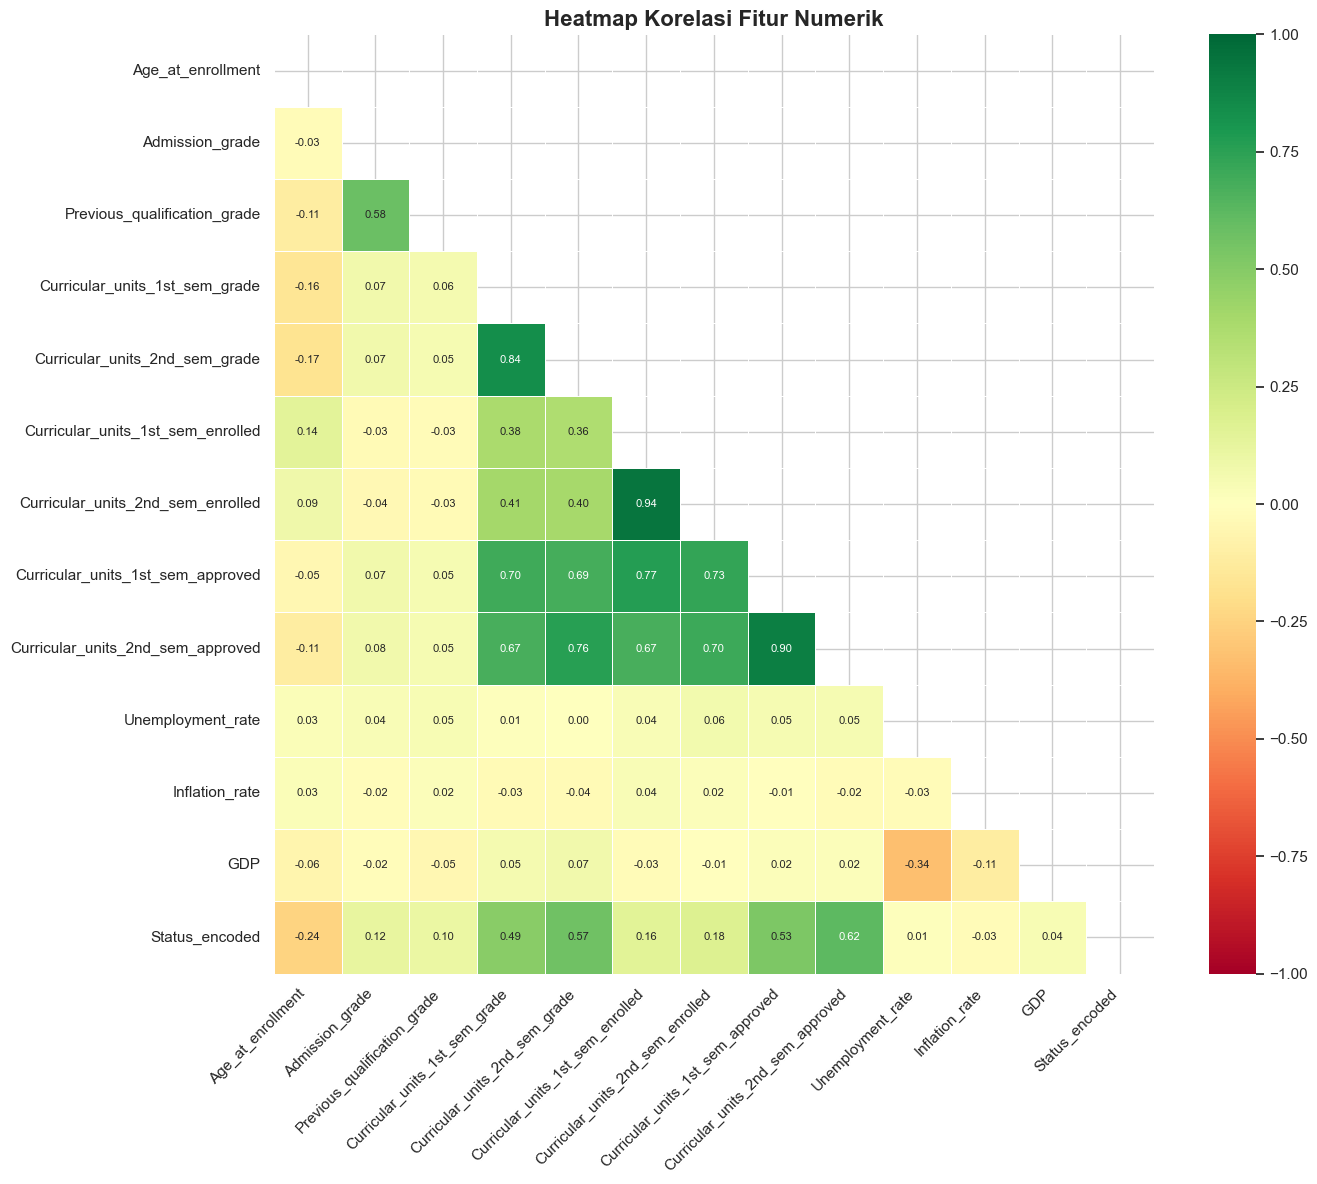

In [13]:
# Encode target untuk korelasi
df_corr = df.copy()
df_corr['Status_encoded'] = LabelEncoder().fit_transform(df_corr['Status'])

corr_cols = numerical_cols + ['Status_encoded']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 3.8 Ringkasan Insight dari EDA

Berdasarkan EDA yang telah dilakukan, diperoleh beberapa insight penting:

1. **Nilai Akademik (Grade Semester 1 & 2)**: Mahasiswa dropout memiliki nilai yang jauh lebih rendah dibandingkan graduate. Ini adalah prediktor terkuat.
2. **Jumlah Unit Disetujui**: Mahasiswa dropout cenderung memiliki unit disetujui yang sangat sedikit, bahkan 0.
3. **Status Pembayaran (Tuition Fees Up To Date)**: Mahasiswa yang tidak membayar biaya kuliah tepat waktu sangat berisiko dropout.
4. **Beasiswa (Scholarship Holder)**: Penerima beasiswa memiliki tingkat dropout yang jauh lebih rendah.
5. **Debtor**: Mahasiswa dengan tunggakan cenderung lebih banyak yang dropout.
6. **Gender**: Perbedaan angka dropout antara pria dan wanita cukup signifikan — pria memiliki angka dropout lebih tinggi.
7. **Course (Program Studi)**: Ada variasi signifikan antar program studi dalam hal angka dropout.
8. **Usia Saat Mendaftar**: Mahasiswa yang mendaftar di usia lebih tua cenderung lebih berisiko dropout.


## 4. Data Preparation

Sesuai dengan tujuan pemodelan — yaitu memprediksi apakah mahasiswa akan **Dropout** atau **Graduate** —
maka hanya data dengan status `Dropout` dan `Graduate` yang digunakan untuk pelatihan model.

> **Catatan**: Data mahasiswa berstatus `Enrolled` disimpan terpisah untuk digunakan sebagai input prediksi di masa mendatang.


In [14]:
# Pisahkan data Enrolled untuk prediksi masa mendatang
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
print(f'Jumlah mahasiswa Enrolled (disimpan untuk prediksi): {len(df_enrolled)}')

# Simpan data Enrolled
if not os.path.exists('data'):
    os.makedirs('data')
df_enrolled.to_csv('data/enrolled_for_prediction.csv', index=False)
print('Data Enrolled berhasil disimpan di data/enrolled_for_prediction.csv')


Jumlah mahasiswa Enrolled (disimpan untuk prediksi): 794
Data Enrolled berhasil disimpan di data/enrolled_for_prediction.csv


In [15]:
# Filter hanya Dropout dan Graduate
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f'Shape dataset setelah filter: {df_model.shape}')
print(f'\nDistribusi Status setelah filter:')
print(df_model['Status'].value_counts())
print(f'\nProporsi:')
print(df_model['Status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Shape dataset setelah filter: (3630, 37)

Distribusi Status setelah filter:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Proporsi:
Status
Graduate    60.85%
Dropout     39.15%
Name: proportion, dtype: object


Distribusi Target Binary:
Target
0    2209
1    1421
Name: count, dtype: int64

0 = Graduate: 2209
1 = Dropout : 1421


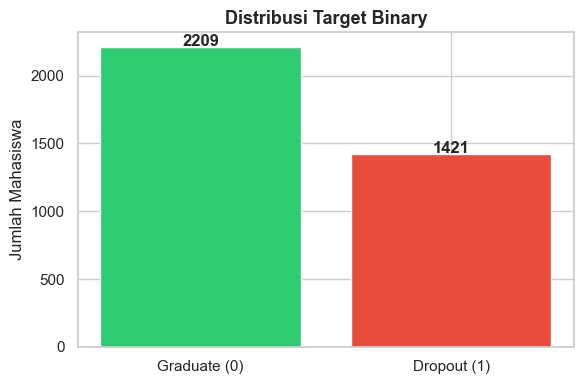

In [16]:
# Buat binary target: 1 = Dropout, 0 = Graduate
df_model['Target'] = (df_model['Status'] == 'Dropout').astype(int)

# Verifikasi distribusi target
print('Distribusi Target Binary:')
print(df_model['Target'].value_counts())
print(f"\n0 = Graduate: {(df_model['Target']==0).sum()}")
print(f"1 = Dropout : {(df_model['Target']==1).sum()}")

# Visualisasi distribusi target binary
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = df_model['Target'].value_counts()
ax.bar(['Graduate (0)', 'Dropout (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Distribusi Target Binary', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
# Simpan data bersih (Dropout + Graduate) untuk dashboard
df_model.to_csv('data/cleaned_data.csv', index=False)
print('Data bersih (Dropout + Graduate) disimpan di data/cleaned_data.csv')


Data bersih (Dropout + Graduate) disimpan di data/cleaned_data.csv


In [18]:
# Memisahkan fitur dan target
X = df_model.drop(['Status', 'Target'], axis=1)
y = df_model['Target']

print(f'Jumlah fitur: {X.shape[1]}')
print(f'Jumlah sampel: {X.shape[0]}')
print(f'\nFitur yang digunakan:')
print(list(X.columns))


Jumlah fitur: 36
Jumlah sampel: 3630

Fitur yang digunakan:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 

In [19]:
# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} sampel')
print(f'Testing set : {X_test.shape[0]} sampel')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling selesai.')


Training set: 2904 sampel
Testing set : 726 sampel

Scaling selesai.


## 5. Modeling

Model yang digunakan adalah **Random Forest Classifier** — sebuah ensemble method yang robust dan efektif untuk klasifikasi biner.

In [20]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print('Model berhasil dilatih.')

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


Model berhasil dilatih.


## 6. Evaluation

In [21]:
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'ROC-AUC  : {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))


Accuracy : 0.9229 (92.29%)
ROC-AUC  : 0.9706

Classification Report:
              precision    recall  f1-score   support

Graduate (0)       0.92      0.95      0.94       442
 Dropout (1)       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



In [22]:
# Cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy (5-fold):')
print(f'  Scores : {cv_scores.round(4)}')
print(f'  Mean   : {cv_scores.mean():.4f}')
print(f'  Std    : {cv_scores.std():.4f}')


Cross-Validation Accuracy (5-fold):
  Scores : [0.8933 0.8864 0.9053 0.9122 0.9052]
  Mean   : 0.9005
  Std    : 0.0093


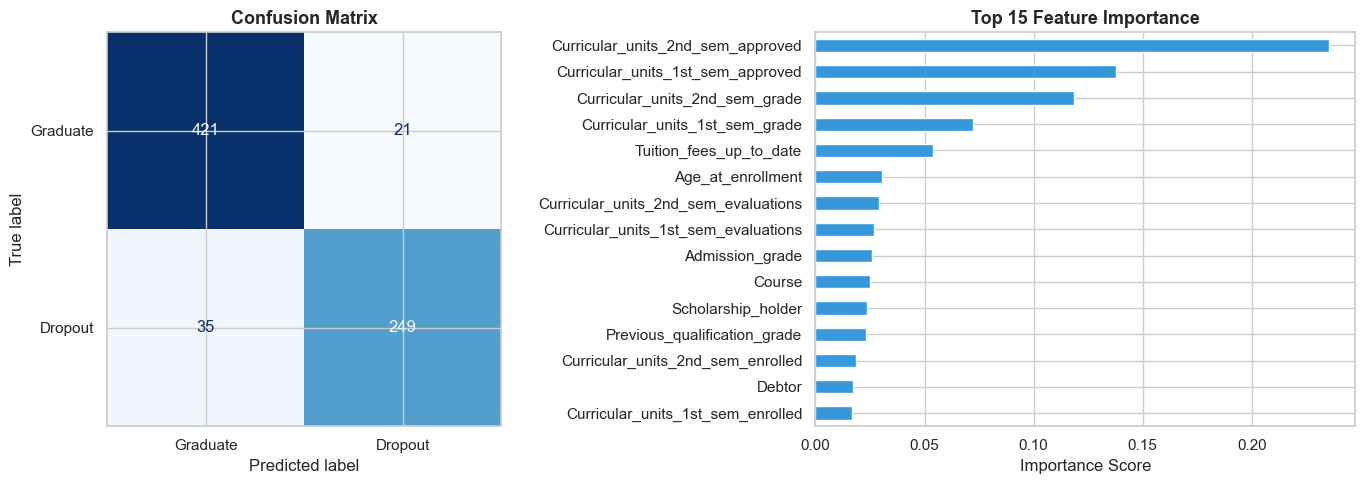

In [23]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Graduate', 'Dropout'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Feature Importance
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True).tail(15)

feat_importance.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Top 15 Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 7. Simpan Model & Scaler

In [24]:
if not os.path.exists('model'):
    os.makedirs('model')

# Simpan binary label encoder (1=Dropout, 0=Graduate)
label_encoder = LabelEncoder()
label_encoder.fit(['Graduate', 'Dropout'])  # 0=Dropout, 1=Graduate

joblib.dump(model, 'model/random_forest_model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(label_encoder, 'model/label_encoder.joblib')

print('Model, scaler, dan label encoder berhasil disimpan.')
print('  - model/random_forest_model.joblib')
print('  - model/scaler.joblib')
print('  - model/label_encoder.joblib')


Model, scaler, dan label encoder berhasil disimpan.
  - model/random_forest_model.joblib
  - model/scaler.joblib
  - model/label_encoder.joblib
